<a href="https://colab.research.google.com/github/cesar-aguera/Data-Science-I-Fundamentos-para-la-Ciencia-de-Datos/blob/main/Modulo_1_2%C2%B0_intento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- PASO 1: Recolección de Datos (Infraestructura) ---
Registros brutos detectados: 8

--- PASO 2: Desarrollo de Capacidades Analíticas (Limpieza) ---
¡Datos consolidados y limpios con éxito!

--- PASO 3: Producto de Datos (Alerta de Reabastecimiento) ---
    Nombre  Autonomia_Dias
0   Laptop             3.1
1    Mouse             1.0
3  Teclado             3.8
5  Hub USB             1.5


--- PASO 4: Visualización (Interpretación de resultados) ---


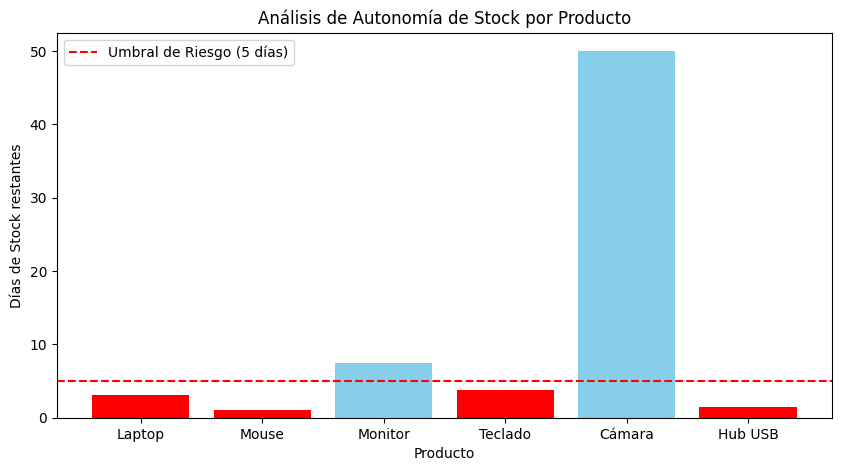


--- PASO 5: Medición y Estrategia ---
Resultado: Se deben pedir unidades de ['Laptop', 'Mouse', 'Teclado', 'Hub USB'] inmediatamente.
Acción Cloud: Este reporte se enviaría automáticamente vía SaaS (Google Workspace) al equipo de compras.


In [ ]:
# ==============================================================================
# UNIDAD 4: CICLO DE VIDA Y ESTRATEGIA DATA-DRIVEN
# Ejemplo: Optimización de Inventario basada en Datos
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

# --- 1. INFRAESTRUCTURA Y RECOLECCIÓN (Simulando una Base de Datos NoSQL/SQL) ---
# En una estrategia Data-Driven, primero recolectamos datos de diversas fuentes.
print("--- PASO 1: Recolección de Datos (Infraestructura) ---")
data = {
    'ID_Producto': [101, 102, 103, 104, 105, 106, 101, 103],
    'Nombre': ['Laptop', 'Mouse', 'Monitor', 'Teclado', 'Cámara', 'Hub USB', 'Laptop', 'Monitor'],
    'Ventas_Mensuales': [50, 150, 80, 120, 30, 200, 55, 75],
    'Stock_Actual': [10, 5, 40, 15, 50, 10, 12, 38],
    'Categoria': ['Electrónica', 'Accesorios', 'Electrónica', 'Accesorios', 'Fotografía', 'Accesorios', 'Electrónica', 'Electrónica']
}
df_raw = pd.DataFrame(data)
print(f"Registros brutos detectados: {len(df_raw)}\n")

# --- 2. CAPACIDADES ANALÍTICAS (Limpieza y Consolidación) ---
# Aplicamos lo aprendido: identificar duplicados y consolidar registros.
print("--- PASO 2: Desarrollo de Capacidades Analíticas (Limpieza) ---")
# Marcamos duplicados para transparencia (Criterio: ID_Producto)
df_raw['Es_Duplicado'] = df_raw.duplicated(subset=['ID_Producto'], keep=False)

# Consolidamos: Sumamos ventas y promediamos stock para registros repetidos
df_clean = df_raw.groupby(['ID_Producto', 'Nombre', 'Categoria']).agg({
    'Ventas_Mensuales': 'sum',
    'Stock_Actual': 'mean'
}).reset_index()
print("¡Datos consolidados y limpios con éxito!\n")

# --- 3. CREACIÓN DE PRODUCTOS DE DATOS (Insight Accionable) ---
# Creamos una métrica: "Días de Autonomía de Stock"
df_clean['Autonomia_Dias'] = (df_clean['Stock_Actual'] / df_clean['Ventas_Mensuales'] * 30).round(1)

# Identificamos productos en riesgo (Estrategia Data-Driven para decidir reabastecimiento)
riesgo = df_clean[df_clean['Autonomia_Dias'] < 5]
print("--- PASO 3: Producto de Datos (Alerta de Reabastecimiento) ---")
print(riesgo[['Nombre', 'Autonomia_Dias']])
print("\n")

# --- 4. VISUALIZACIÓN DE DATOS (Comunicación de Resultados) ---
# Usamos herramientas de visualización para que los tomadores de decisiones entiendan el ROI.
print("--- PASO 4: Visualización (Interpretación de resultados) ---")
plt.figure(figsize=(10, 5))
colors = ['red' if x < 5 else 'skyblue' for x in df_clean['Autonomia_Dias']]
plt.bar(df_clean['Nombre'], df_clean['Autonomia_Dias'], color=colors)
plt.axhline(y=5, color='r', linestyle='--', label='Umbral de Riesgo (5 días)')
plt.title('Análisis de Autonomía de Stock por Producto')
plt.xlabel('Producto')
plt.ylabel('Días de Stock restantes')
plt.legend()
plt.show()

# --- 5. MEDIR Y OPTIMIZAR (Cierre del Ciclo) ---
print("\n--- PASO 5: Medición y Estrategia ---")
print(f"Resultado: Se deben pedir unidades de {riesgo['Nombre'].tolist()} inmediatamente.")
print("Acción Cloud: Este reporte se enviaría automáticamente vía SaaS (Google Workspace) al equipo de compras.")

In [ ]:
def calcular_area(largo, ancho):
    area = largo * ancho
    return area

# Uso de la función
resultado = calcular_area(5, 3)
print(f"El área del rectángulo es: {resultado}")


El área del rectángulo es: 15
